# UltraPlot

## Introduction

UltraPlot is an information visualization plotting package that works as a wrapper for Matplotlib, providing an efficient way to create more detailed and complicated figures than what we can make with Matplotlib.
It subclasses these three fundamental classes:
 - Figure for `matplotlib.figure.Figure`
 - Axes for `matplotlib.axes.Axes`
 - GridSpec for `matplotlib.grispec.GridSpec`

UltraPLot uses the general Matplotlib code we're familiar with three key commands:
 - `.figure()`
 - `.subplot()`
 - `.subplots()`

Much of the formatting that takes up many lines of codes such as `.set_xlabel()` or `.set_yticklabels()` are conveniently condensed using `.format()`. Labels, axis limits, ticks, grids, and more can be customized in this one command, rather than having to repeat `ax.command()` for different aspects of the figure.

It is not a particularly interactive package, focusing mainly on improving customization and detail. There are a lot more options for named colors and many fonts to choose from. UltraPlot expands on the use of subplots, with better rearrangement and layout management techniques, and has multiple layers to add detail to each figure.

A wide variety of plots can be made using this package:
 - using axes:
     - cartesian - typical x & y plots
     - geographic - longitude & latitude plots
     - polar - azimuth & radius plots
 -  statistical plots
     - violin plots, histograms, ridgeline
 - colormaps
 - 1D & 2D plots
 - network plots

## Installation

UltraPlot is only compatible with Python versions *before* 3.14, meaning the newest version will not run.

### Windows
**Check correct Python installation:**
python --version
pip --version

If Python does not exist on your computer, download version 3.11x from this page: https://www.python.org/downloads/windows/ and select "add to PATH".

python -m pip install networkx

**In Jupyter:**
import ultraplot as uplt

### macOS
**Check correct Python installation:**
python3 --version

pip install --upgrade pip
pip install ultraplot

**In Jupyter:**
import ultraplot as uplt

## Quick Start Example

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import ultraplot as uplt

In [2]:
import sys
print(sys.executable)

/Users/evijonas/python/archyviz/bin/python3


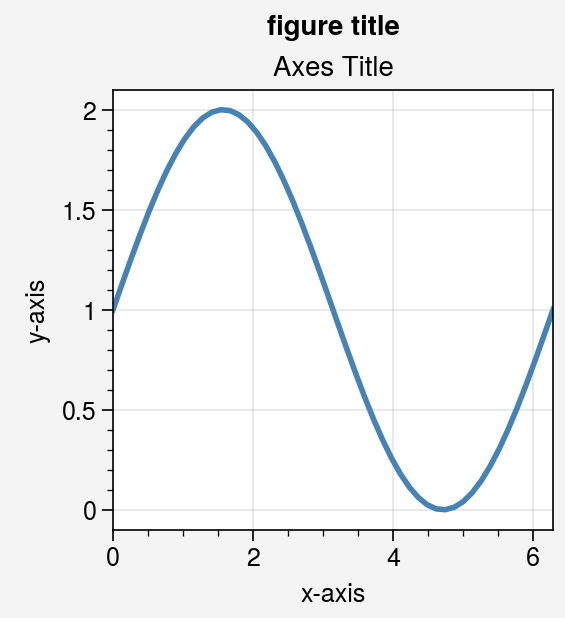

In [5]:
# data
x = np.linspace(0, 2*np.pi)
y = np.sin(x)

# creates a figure
fig = uplt.figure(refwidth = 2.2)

# add an axes
ax = fig.subplot(title='Axes Title')

# plot the data
ax.plot(x, y + 1, linewidth=2, color='steelblue')

# format the figure
fig.format(suptitle='figure title', xlabel='x-axis', ylabel='y-axis')

uplt.show()

## Negative and Positive Colors - Example 1

`negpos` is UltraPlot's colormap normalizer, specifically designed to highlight positive vs. negative values.

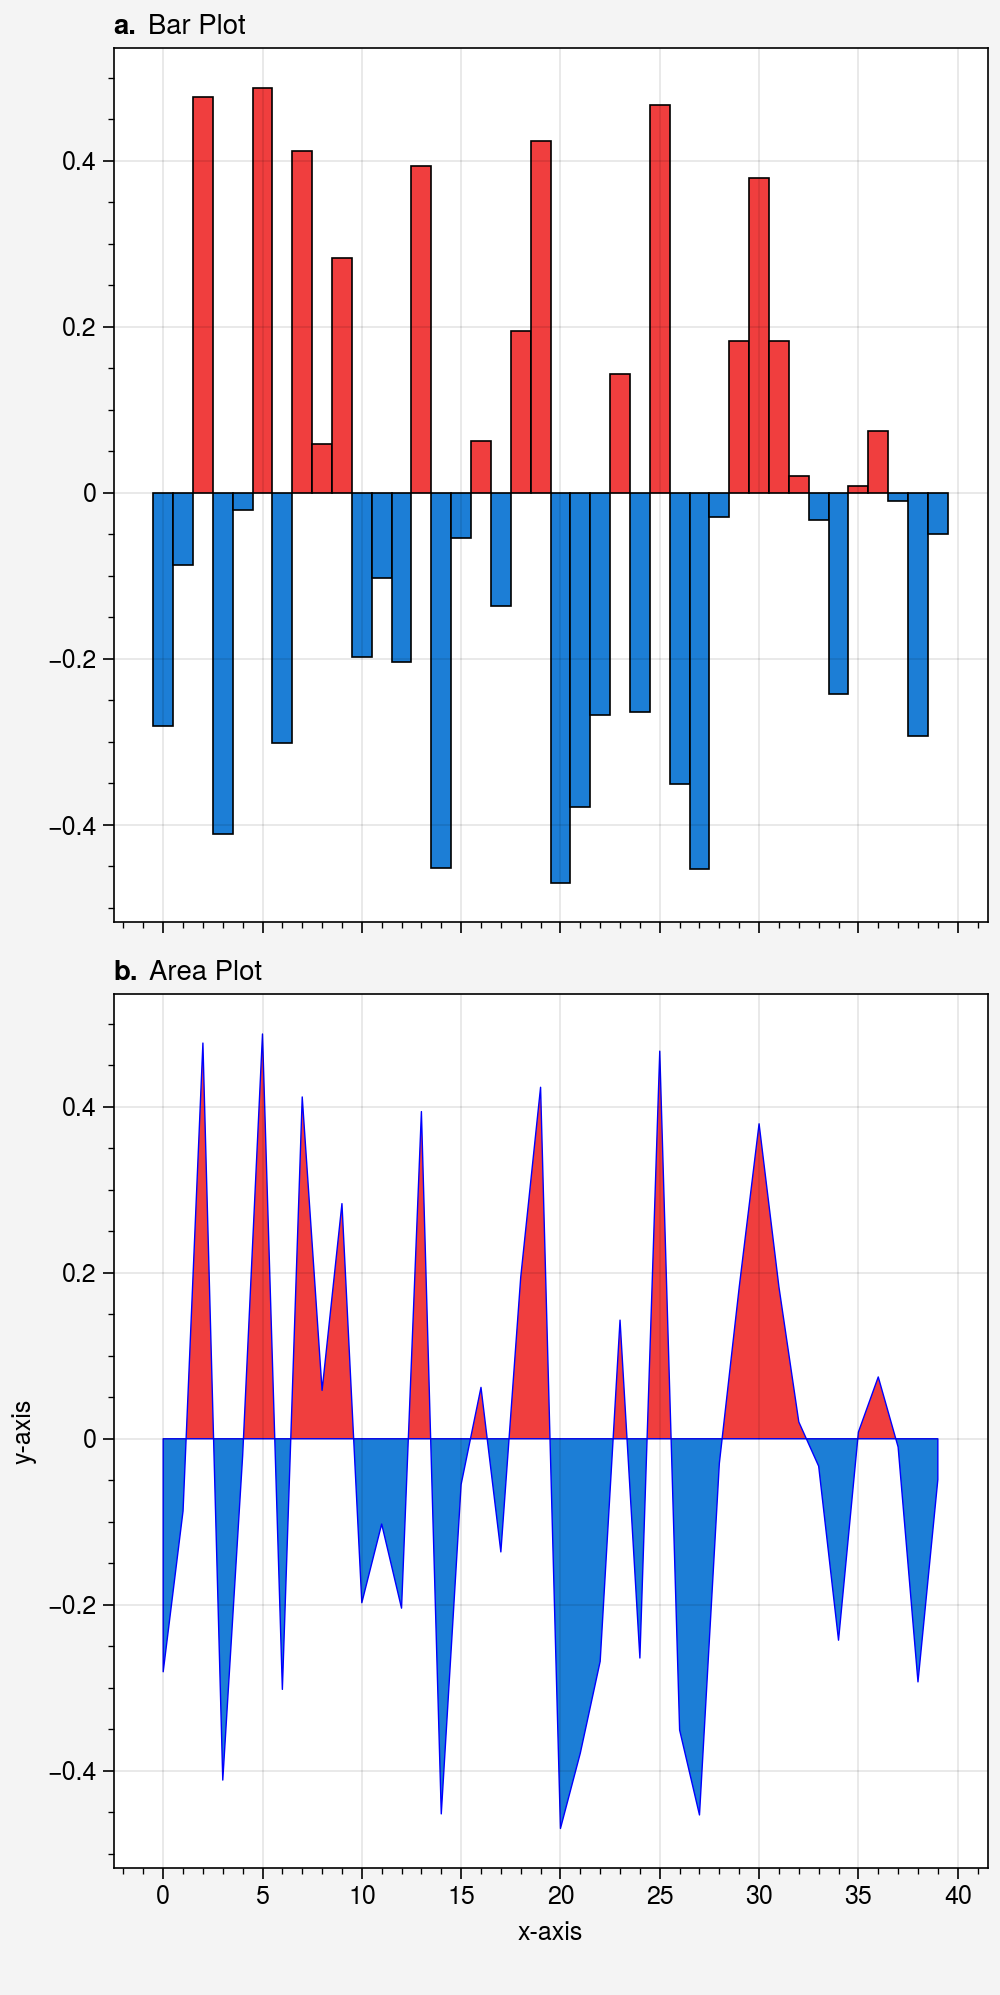

In [6]:
# randomized data
state = np.random.RandomState(2026)
data = state.rand(40) - 0.5

# format
uplt.rc.abc = 'a.' # alphabetical ordering
uplt.rc.titleloc = 'l' # title alignment 

# figure
fig, axs = uplt.subplots(nrows=2, figwidth=5)

# bar plot
axs[0].bar(data, width=1, negpos=True, edgecolor='k') # k is shorthand for black
axs[0].format(title='Bar Plot')

# area plot
axs[1].area(data, negpos=True, lw=0.5, edgecolor='b') # b is shorthand for blue
axs[1].format(title='Area Plot', xlabel='x-axis', ylabel='y-axis')

uplt.show()

## Contour Heatmap - Example 2

UltraPlot allows easy creation of filled contours on a plot using `ax.contourf()`, making it ideal for geographical visualization. It also can overlay contour lines and provide automatic legends as seen below with `ax.contour()`.

This is overall less verbose than Matplotlib.

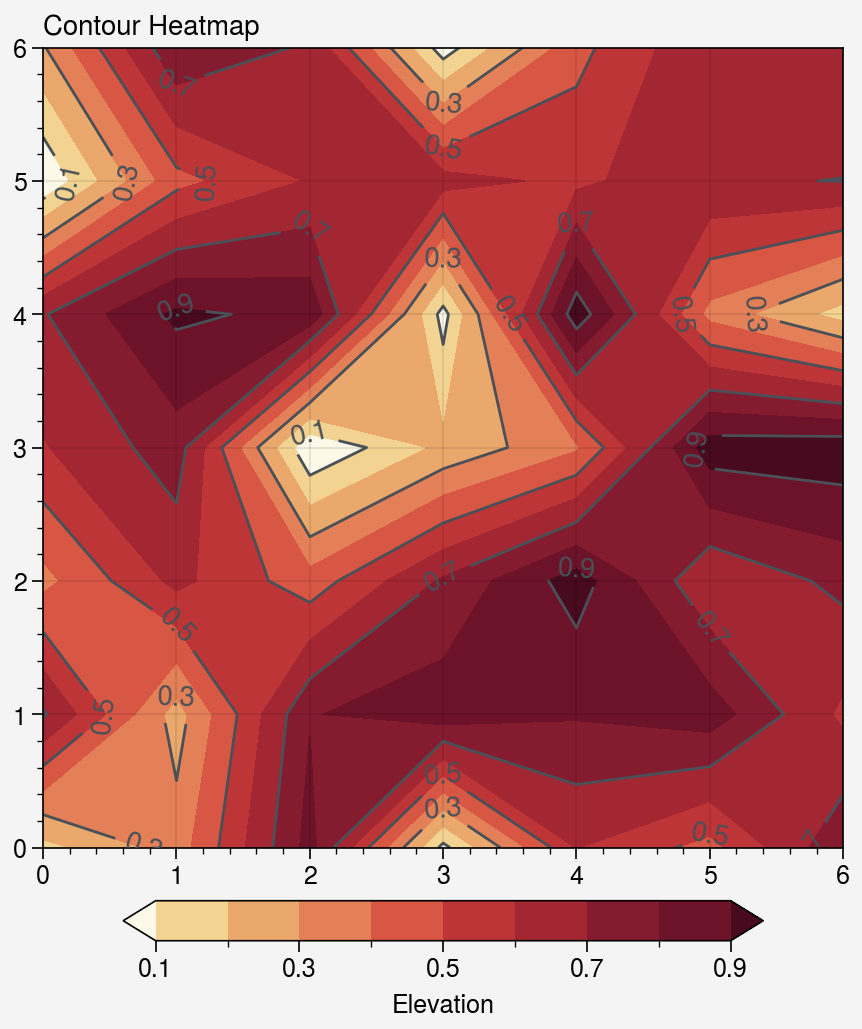

In [8]:
# data
state = np.random.RandomState(20543)
data = state.rand(7, 7)

# figure
fig, ax = uplt.subplots(refwidth=4)
ax.format(title='Contour Heatmap', abc=False)

# filled contour
ax.contourf(
    data,
    cmap='Reds1',
    extend='both',#maybe no''
    colorbar='b',
    colorbar_kw={'length':0.8, 'label':'Elevation'}
)

# line contours with levels and labels
levels = [0.1,0.3,0.5,0.7,0.9]
cs = ax.contour(
    data,
    levels=levels,
    color='gray7',
    lw=1
)

# label each contour line
ax.clabel(cs, inline=True, fmt='%0.1f', fontsize=10)

uplt.show()

## Colormap - Example 3

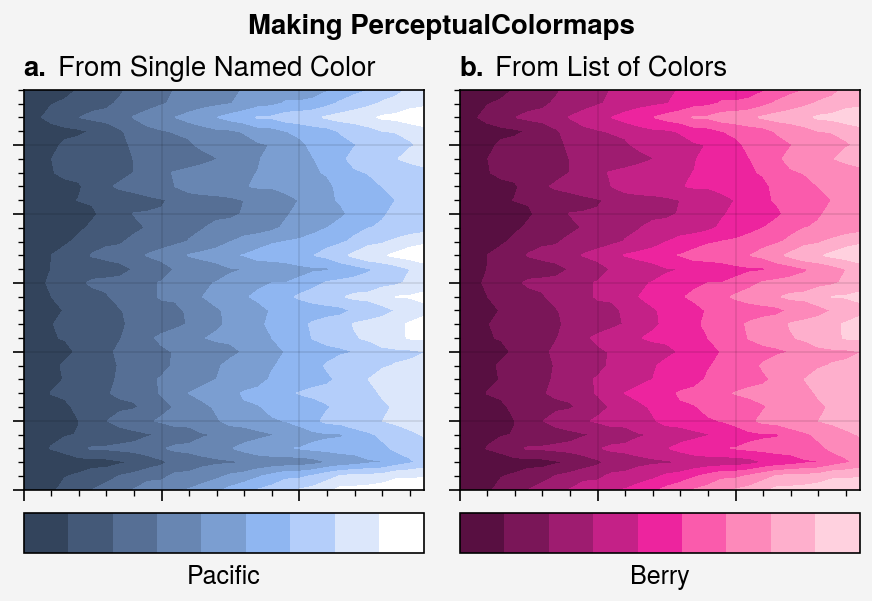

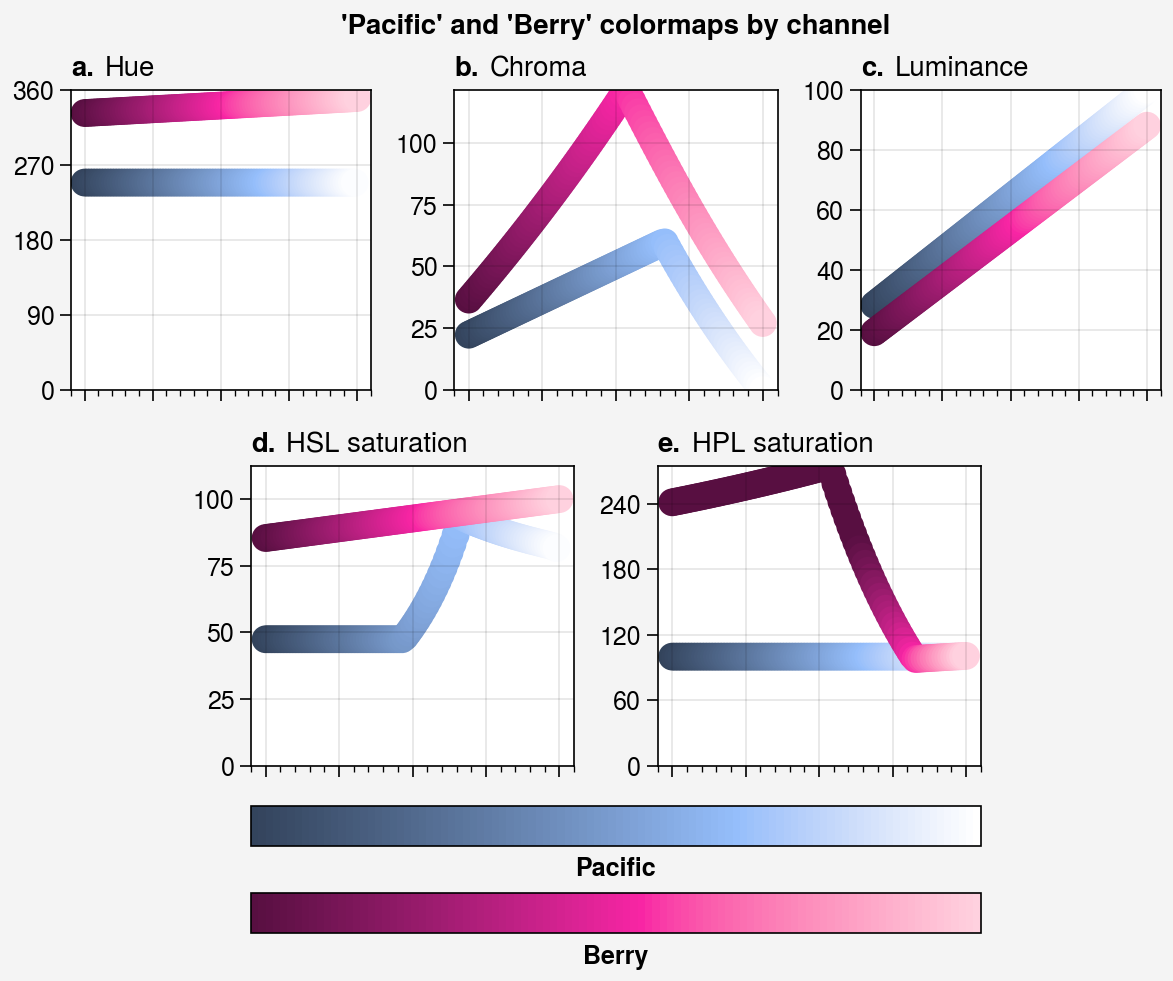

In [9]:
# structures depiction of change in color
state = np.random.RandomState(51423)
data = state.rand(30, 30).cumsum(axis=1)

# figure
fig = uplt.figure(refwidth=2, span=False)

# from a color
ax = fig.subplot(121, title="From Single Named Color")
cmap1 = uplt.Colormap('prussian blue_r', l=100,
                      name='Pacific', space="hpl") # '_r' makes cmap dark -> light rather than light -> dark
m = ax.contourf(data, cmap=cmap1)
ax.colorbar(m, loc='b',
            ticks="none", label=cmap1.name)

# from lists
ax = fig.subplot(122, title="From List of Colors")
cmap2 = uplt.Colormap(("plum", "light pink"),
                      name="Berry")
m = ax.contourf(data, cmap=cmap2)
ax.colorbar(m, loc='b',
            ticks="none", label=cmap2.name)

# display channels
fig.format(xticklabels="none", yticklabels="none",
           suptitle="Making PerceptualColormaps")
fig, axs = uplt.show_channels(cmap1, cmap2, refwidth=1.5, rgb=False)

## Customized Networks - Complex Example

#### Additional Installation of `networkx` and `scipy`

**Windows:**

In Jupyter: `print(sys.executable)`

In Command Prompt: at the path printed above `python -m pip install networkx` then `python -m pip install scipy`. Restart the kernel.

**macOS**

In Jupyter: `print(sys.executable)` -> `%pip install networkx`and `%pip install scipy`. Restart the kernel.

This ensures that you install `networkx` and `scipy` in the path that Jupyter is running in.

In [11]:
import networkx as nx

#### Networks

A **network** is a collection of things and the connections between them. 

**Nodes** = things, **Edges** = connections

UltraPlot supports plotting networks using networkx. It provides an intuitive interface for plotting networks using `graph()` to plot networks by for visualizing connections.

After plotting a graph, UltraPlot automatically styles with additional customization done using `format()` like before. 

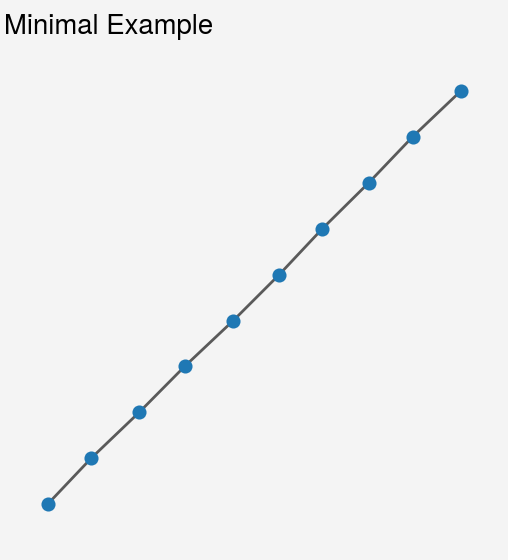

In [13]:
# create a network with 10 nodes
g = nx.path_graph(n=10) 

# figure
fig, ax = uplt.subplots()

# graph
ax.graph(g)

# format
ax.format(title='Minimal Example', abc=False)

uplt.show()

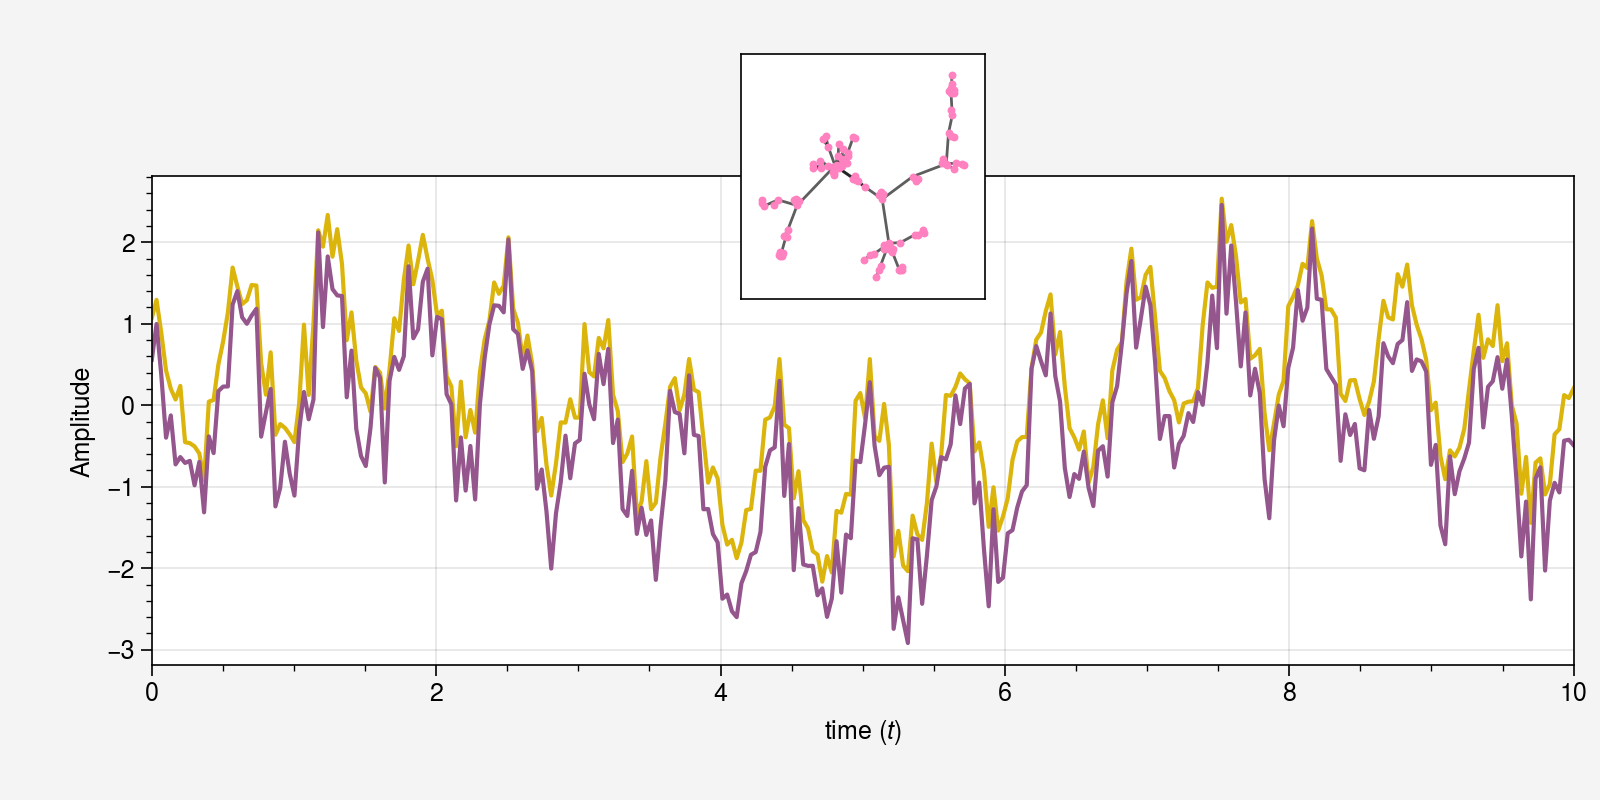

In [18]:
# growing network with 100 nodes
g = nx.gn_graph(n=100).to_undirected()  

# time series data
x = np.linspace(0, 10, 300)
y = np.sin(x) + np.cos(10 * x) + np.random.randn(*x.shape) * 0.3

# figure
fig, ax = uplt.subplots(figsize=(8, 4))

# plot line graph
ax.plot(x, y, color='gold')
ax.plot(x, y - np.random.rand(*x.shape), color='purple')

# format line graph
ax.format(xlabel='time $(t)$', ylabel='Amplitude', abc=False)

# inset axes
inax = ax.inset_axes([0.25, 0.75, 0.5, 0.5], zoom=False)

# graphs g inside inset axes
inax.graph(
    g,
    layout='forceatlas2',
    node_kw=dict(
        node_size=5,    
        node_shape='o',  
        node_color='pink'  
    )
)

# formats g
inax.format(
    facecolor='white',
    xspineloc='both',
    yspineloc='both',
    xlim=None,
    ylim=None
)

uplt.show()

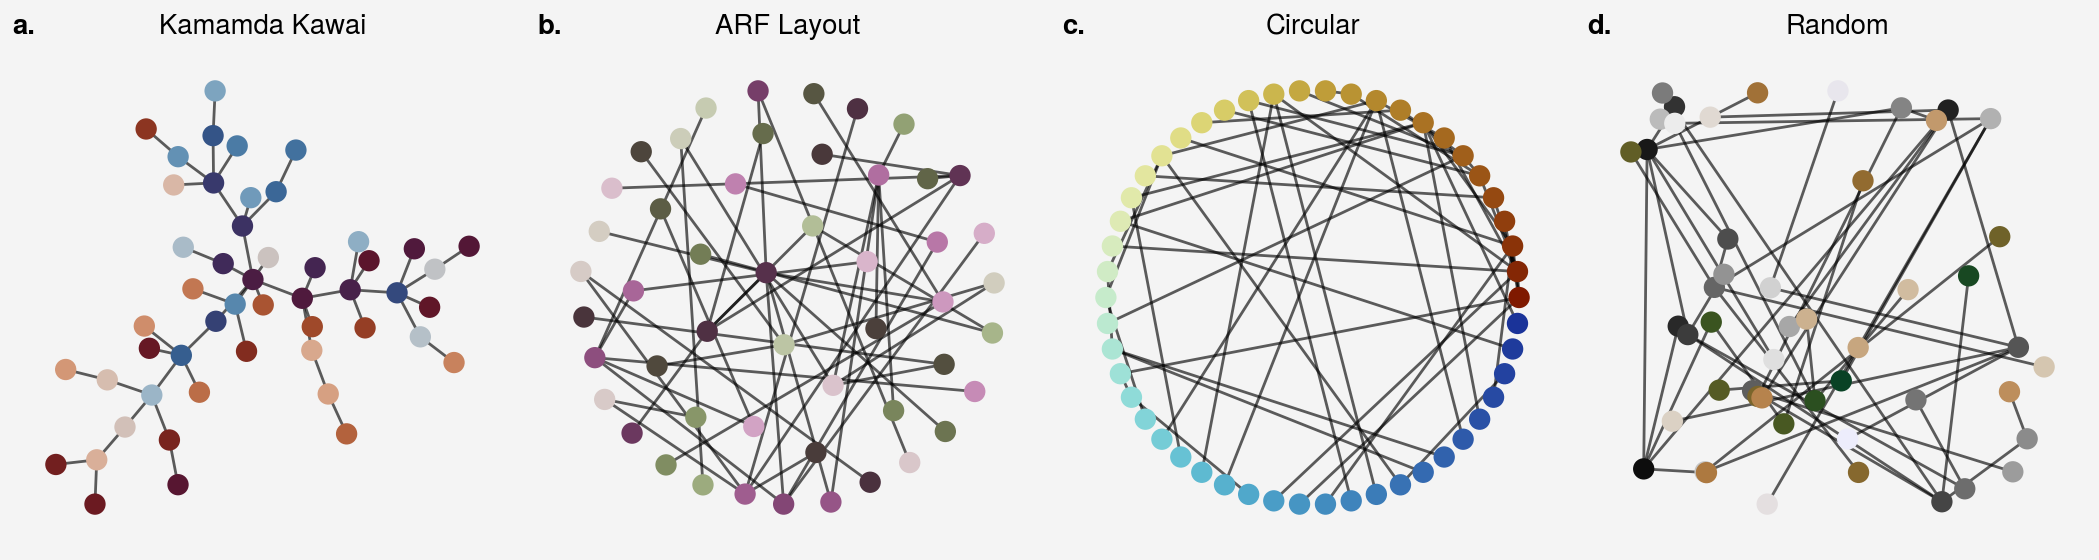

In [19]:
# growing network with 50 nodes
g = nx.gn_graph(50).to_undirected()

# figure
fig, ax = uplt.subplots(ncols=4, refwidth=2.5)

# circular node layout
circular = nx.circular_layout(g)
# defines four node positions
layouts = [None, nx.arf_layout, circular, 'random']
names = ['Kamamda Kawai', 'ARF Layout', 'Circular', 'Random'] 
# UltraPlot color maps
cmap_names = ['viko', 'bamo', 'roma', 'fes']


for axi, layout, name, cmap_name in zip(ax, layouts, names, cmap_names):#note, zip puts the lists side by side in order
    cmap = uplt.Colormap(cmap_name)
   
    colors = [uplt.set_alpha(c, 1.0) for c in cmap(np.linspace(0, 1, g.number_of_nodes()))]

    # graphs networks
    axi.graph(
        g,
        layout=layout,
        node_kw=dict(
            node_color=colors,  
            node_size=50,     
            node_shape='o'
        )
    )
    
    axi.set_title(name)

uplt.show()

## Summary

### Pros
- ability for detailed information visualization
- many customization choices
- simple to use while having high performance
    - less coding & more results

### Cons
- Python version compatibility issues
    - various dependencies required for certain types of plots
- not a fully interactive package
- can be difficult to learn

## Rating: 8/10

Overall: ★★★★☆

Documentation: ★★★★★

Ease of Use: ★★★★☆

Flexibility: ★★★☆☆

Maturity: ★★☆☆☆

Best for simple and user-friendly customization, networks, and lots of flexibility in layout details.
Avoid if you want an interactive dashboard. 